# Fase 1 – Modelo predictivo de precios de viviendas

Proyecto Integrador v1 – 2026 II · Modelos y Simulación de Sistemas I

## 6.1 Introducción

- **Problema seleccionado:** estimar el precio de venta de una vivienda a partir de sus características físicas, de ubicación y de la transacción.
- **Objetivo del modelo:** dada la ficha de una vivienda, predecir su precio de venta en dólares (`SalePrice`). Esta fase busca un proceso **reproducible, documentado y sin fuga de información**, más que el mejor desempeño posible.
- **Tipo de problema:** aprendizaje supervisado – **regresión**.
- **Variable objetivo:** `SalePrice` (precio de venta, USD).
- **Fuente de los datos:** competencia de Kaggle [`aecincode_houseprices`](https://www.kaggle.com/competitions/aecincode_houseprices), basada en el *Ames Housing Dataset* (De Cock, 2011) y relacionada con [House Prices – Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/). Se usa `data/train.csv` (con precio) para entrenar y evaluar, y `data/test.csv` (sin precio) como "datos nuevos" para probar el modelo guardado.
- **Referencias metodológicas:** notebooks de clase NOTES 04.01 (exploración), 04.02 (limpieza y valores faltantes) y 04.03/04.04 (pruebas de hipótesis).

In [1]:
import os, json, platform, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import sklearn

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set()

# ---- configuración global (todo el notebook depende solo de estas constantes) ----
RANDOM_STATE = 42                 # semilla única para split, validación cruzada y modelo
np.random.seed(RANDOM_STATE)
DATA_PATH = "data/train.csv"      # datos con variable objetivo
NEW_DATA_PATH = "data/test.csv"   # datos nuevos (sin variable objetivo)
TARGET = "SalePrice"
IDS = ["Order", "PID", "Id"]      # identificadores: no describen la vivienda
TEST_SIZE = 0.2
MODEL_PATH = "modelo.joblib"

## 6.2 Descripción del conjunto de datos

In [2]:
d = pd.read_csv(DATA_PATH)
predictoras = [c for c in d.columns if c not in IDS + [TARGET]]
print(f"Observaciones: {len(d):,}")
print(f"Columnas: {d.shape[1]} = 1 objetivo + {len(predictoras)} predictoras + {len(IDS)} identificadores")

tipos = d[predictoras].dtypes.map(lambda t: "numérica" if pd.api.types.is_numeric_dtype(t) else "categórica")
print("\nTipos de predictoras:"); print(tipos.value_counts().to_string())
d[TARGET].describe().round(0).to_frame("SalePrice (USD)").T

Observaciones: 1,758
Columnas: 83 = 1 objetivo + 79 predictoras + 3 identificadores

Tipos de predictoras:
categórica    43
numérica      36


,count,mean,std,min,25%,50%,75%,max
SalePrice (USD),1758.0,179194.0,77798.0,12789.0,129425.0,160100.0,210000.0,755000.0


- **Observaciones:** cada fila es la venta de una vivienda distinta. **Variables:** 79 predictoras (36 numéricas y 43 categóricas; `MS SubClass` figura como numérica pero codifica categorías) más el objetivo y tres identificadores (`Order`, `PID`, `Id`) que solo sirven para identificar filas y se excluyen.
- **Variable objetivo:** `SalePrice`, precio de venta en dólares (continua, positiva).
- **Variables predictoras:** dimensiones y áreas (lote, sótano, garaje, pisos), calidad y condición de materiales y acabados (escalas Ex/Gd/TA/Fa/Po), año de construcción y remodelación, barrio, tipo de vivienda y condiciones de la venta.
- **Limitaciones:**
  - Los datos corresponden a una sola ciudad (Ames, Iowa) y a ventas de 2006–2010, por lo que el modelo no generaliza necesariamente a otros mercados ni épocas.
  - Aunque hay una columna de año de venta, **no es un problema de series de tiempo**: cada venta se trata como una observación independiente.
  - Muchos valores vacíos no son datos perdidos sino "la vivienda no tiene esa característica" (se analiza en 6.3 y 6.4).
  - Hay pocos valores atípicos muy influyentes (p. ej. viviendas de más de 4.000 pies² de área habitable).

## 6.3 Exploración de los datos

> **Nota metodológica.** La partición entrenamiento/prueba se documenta en 6.5, pero se ejecuta aquí, al inicio de la exploración, para que **ninguna decisión de análisis o limpieza dependa del conjunto de prueba**. Desde este punto, todo análisis que involucre el precio usa solo `X_train`/`y_train`. Únicamente la cuantificación de valores faltantes se hace sobre el conjunto completo porque no depende del objetivo.

In [3]:
X = d[predictoras]          # sin objetivo y sin identificadores
y = d[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
print("train:", X_train.shape, "| test:", X_test.shape)

train: (1406, 79) | test: (352, 79)


### Valores faltantes por variable

In [4]:
faltantes = X.isna().sum().to_frame("n_faltantes")
faltantes["% faltante"] = (faltantes["n_faltantes"] / len(X) * 100).round(2)
faltantes = faltantes[faltantes["n_faltantes"] > 0].sort_values("% faltante")
faltantes["en rango 0.1%-2%"] = faltantes["% faltante"].between(0.1, 2)
print(f"{len(faltantes)} de {X.shape[1]} predictoras tienen valores faltantes")
print("En el rango 0.1%-2%:", list(faltantes.index[faltantes["en rango 0.1%-2%"]]))
faltantes

26 de 79 predictoras tienen valores faltantes
En el rango 0.1%-2%: ['Mas Vnr Area']


,n_faltantes,% faltante,en rango 0.1%-2%
Total Bsmt SF,1,0.06,False
Bsmt Unf SF,1,0.06,False
Bsmt Full Bath,1,0.06,False
Bsmt Half Bath,1,0.06,False
BsmtFin SF 2,1,0.06,False
BsmtFin SF 1,1,0.06,False
Garage Area,1,0.06,False
Garage Cars,1,0.06,False
Mas Vnr Area,12,0.68,True
Bsmt Cond,42,2.39,False


¿Son datos perdidos o "no aplica"? Para varias variables (sótano, garaje, chimenea, piscina) comprobamos si el vacío coincide con que la característica no existe, usando una variable numérica de referencia (p. ej. `Bsmt Qual` vacío vs `Total Bsmt SF == 0`).

In [5]:
chequeos = {"Bsmt Qual": "Total Bsmt SF", "Bsmt Cond": "Total Bsmt SF", "Garage Type": "Garage Area",
            "Garage Finish": "Garage Area", "Fireplace Qu": "Fireplaces", "Pool QC": "Pool Area"}
filas = []
for col, ref in chequeos.items():
    sin = X[ref] == 0
    filas.append({"variable": col, "referencia": f"{ref} == 0", "nulos": int(X[col].isna().sum()),
                  "filas sin la característica": int(sin.sum()),
                  "nulos que coinciden": int((X[col].isna() & sin).sum())})
pd.DataFrame(filas).set_index("variable")

,referencia,nulos,filas sin la característica,nulos que coinciden
variable,,,,
Bsmt Qual,Total Bsmt SF == 0,42,41,41
Bsmt Cond,Total Bsmt SF == 0,42,41,41
Garage Type,Garage Area == 0,98,98,98
Garage Finish,Garage Area == 0,99,98,98
Fireplace Qu,Fireplaces == 0,877,877,877
Pool QC,Pool Area == 0,1752,1752,1752


**Conclusión:** casi todos los vacíos de sótano, garaje, chimenea y piscina son **ausencia de la característica**, no información perdida. Solo `Lot Frontage`, `Mas Vnr Area`, `Garage Yr Blt` (en parte) y unas pocas filas con una sola medida faltante son faltantes reales. Esto condiciona la estrategia de tratamiento (6.4).

### Distribución de la variable objetivo (train)

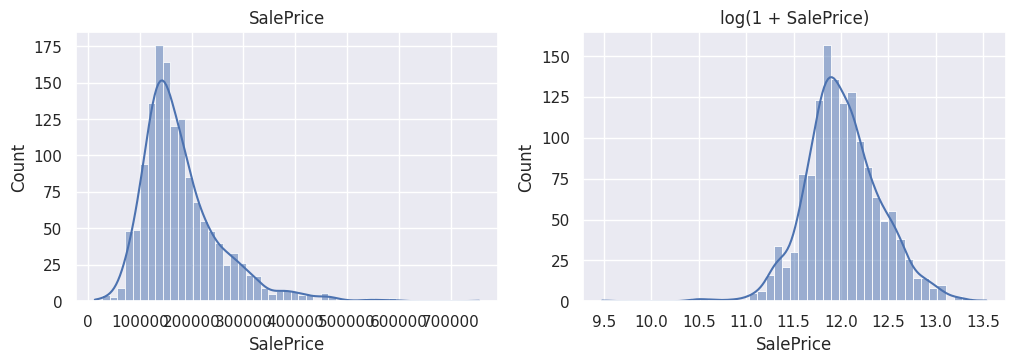

asimetría original: 1.74 | asimetría con log: -0.02


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
sns.histplot(y_train, kde=True, ax=ax[0]); ax[0].set_title("SalePrice")
sns.histplot(np.log1p(y_train), kde=True, ax=ax[1]); ax[1].set_title("log(1 + SalePrice)")
plt.show()
print("asimetría original: %.2f | asimetría con log: %.2f" % (y_train.skew(), np.log1p(y_train).skew()))

El precio es asimétrico a la derecha (pocas viviendas muy caras). Con el logaritmo la distribución queda casi simétrica; por eso el modelo se entrenará sobre `log(1 + precio)` y las métricas se reportarán en dólares.

### Estadísticas descriptivas (train)

In [7]:
X_train.select_dtypes(include="number").describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
MS SubClass,1406.0,57.5,43.0,20.0,20.0,50.0,70.0,190.0
Lot Frontage,1163.0,69.4,23.1,21.0,58.0,68.0,80.0,313.0
Lot Area,1406.0,10172.0,7726.6,1470.0,7500.0,9410.5,11555.2,164660.0
Overall Qual,1406.0,6.1,1.4,1.0,5.0,6.0,7.0,10.0
Overall Cond,1406.0,5.6,1.1,1.0,5.0,5.0,6.0,9.0
Year Built,1406.0,1970.6,30.6,1872.0,1953.2,1972.0,2000.0,2010.0
Year Remod/Add,1406.0,1984.7,20.7,1950.0,1966.0,1994.0,2004.0,2010.0
Mas Vnr Area,1396.0,103.9,178.1,0.0,0.0,0.0,165.2,1290.0
BsmtFin SF 1,1405.0,439.6,441.2,0.0,0.0,376.0,729.0,4010.0
BsmtFin SF 2,1405.0,49.5,172.7,0.0,0.0,0.0,0.0,1526.0


### Relación entre predictoras y objetivo (train)

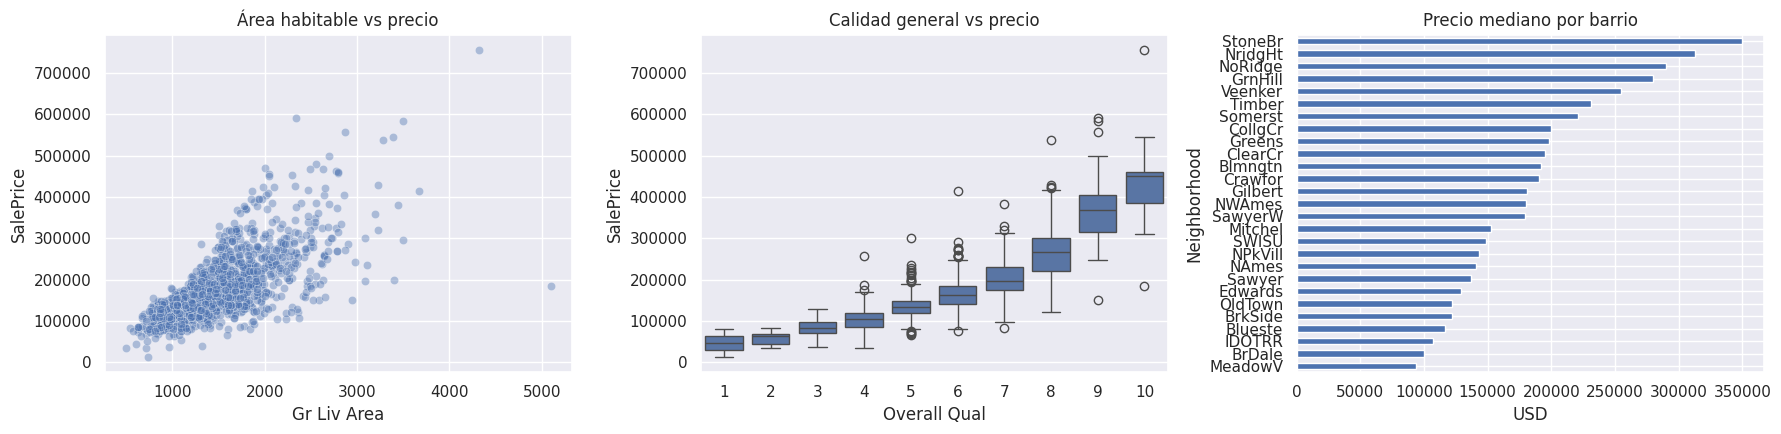

In [8]:
tr = X_train.assign(**{TARGET: y_train})
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
sns.scatterplot(data=tr, x="Gr Liv Area", y=TARGET, alpha=.4, ax=ax[0]); ax[0].set_title("Área habitable vs precio")
sns.boxplot(data=tr, x="Overall Qual", y=TARGET, ax=ax[1]); ax[1].set_title("Calidad general vs precio")
med = tr.groupby("Neighborhood")[TARGET].median().sort_values()
med.plot.barh(ax=ax[2]); ax[2].set_title("Precio mediano por barrio"); ax[2].set_xlabel("USD")
plt.tight_layout(); plt.show()

- El precio crece de forma casi lineal con el área habitable y de forma monótona con la calidad general.
- El barrio separa claramente segmentos de precio (variable categórica muy informativa).
- Se observan viviendas muy grandes que se salen del patrón (las revisamos abajo).

In [9]:
tr.loc[tr["Gr Liv Area"] > 4000, ["Gr Liv Area", "Overall Qual", "Neighborhood", TARGET]]

,Gr Liv Area,Overall Qual,Neighborhood,SalePrice
329,4316,10,NoRidge,755000
1048,5095,10,Edwards,183850


### Análisis de correlación entre variables numéricas (train)

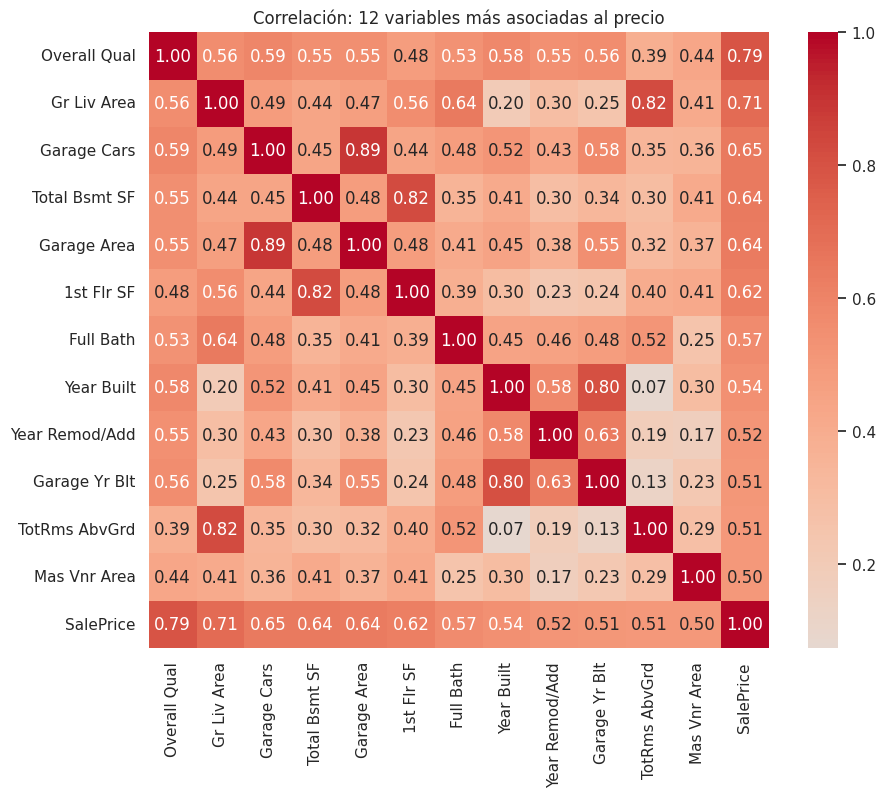

Pares de predictoras con |r| > 0.8:


,variable_1,variable_2,r
0,Garage Cars,Garage Area,0.89
1,Total Bsmt SF,1st Flr SF,0.82
2,Gr Liv Area,TotRms AbvGrd,0.82
3,Year Built,Garage Yr Blt,0.80


In [10]:
num_pred = X_train.select_dtypes(include="number").drop(columns=["MS SubClass"])  # MS SubClass son códigos
corr_obj = num_pred.corrwith(y_train).abs().sort_values(ascending=False)
top = list(corr_obj.head(12).index)

plt.figure(figsize=(10, 8))
sns.heatmap(num_pred[top].assign(**{TARGET: y_train}).corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación: 12 variables más asociadas al precio"); plt.show()

cm = num_pred.corr()
pares = cm.where(np.triu(np.ones(cm.shape, dtype=bool), k=1)).stack().reset_index()
pares.columns = ["variable_1", "variable_2", "r"]
pares = pares[pares["r"].abs() > 0.8].sort_values("r", key=abs, ascending=False).reset_index(drop=True)
print("Pares de predictoras con |r| > 0.8:")
pares.round(2)

**Lectura y decisión sobre las variables muy correlacionadas.**

- Con el precio, las más correlacionadas son `Overall Qual` (calidad general), `Gr Liv Area` (área habitable) y las de garaje y sótano.
- Entre predictoras hay cuatro pares redundantes (|r| > 0.8): `Garage Cars`–`Garage Area`, `Total Bsmt SF`–`1st Flr SF`, `Gr Liv Area`–`TotRms AbvGrd` y `Year Built`–`Garage Yr Blt`.
- **Decisión: se conservan todas.** (i) El modelo elegido está basado en árboles, que no sufren la inestabilidad de coeficientes que la multicolinealidad causa en regresiones lineales; a lo sumo reparte la importancia entre las variables redundantes. (ii) Cada par aporta matices (p. ej. área habitable vs. número de habitaciones). (iii) `Garage Yr Blt` tiene un indicador de ausencia que aporta información sobre la existencia del garaje. (iv) En esta fase el equipo no descarta variables sin evidencia de que mejore el modelo. Si se usara un modelo lineal habría que revisar esta decisión.

## 6.4 Preparación de los datos

### Estrategia para los valores faltantes

Antes de decidir, medimos el posible impacto: si los vacíos de una variable se asocian a un precio distinto, el vacío **contiene información** y borrarlo o disfrazarlo (p. ej. con la moda) la destruiría.

In [11]:
NO_APLICA = ["Alley", "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2",
             "Fireplace Qu", "Garage Type", "Garage Finish", "Garage Qual", "Garage Cond", "Garage Yr Blt",
             "Pool QC", "Fence", "Misc Feature", "Mas Vnr Type"]   # vacío = la vivienda no tiene la característica

filas = []
for col in faltantes.index:
    m = X_train[col].isna()
    es_num = pd.api.types.is_numeric_dtype(X_train[col])
    filas.append({"variable": col, "n_train": int(m.sum()),
                  "precio medio si falta": y_train[m].mean() if m.sum() else np.nan,
                  "precio medio si no falta": y_train[~m].mean(),
                  "naturaleza": "no aplica" if col in NO_APLICA else "dato faltante real",
                  "estrategia": "mediana + indicador de ausencia" if es_num else 'categoría "None"'})
impacto = pd.DataFrame(filas).set_index("variable")
impacto[["precio medio si falta", "precio medio si no falta"]] = impacto[["precio medio si falta", "precio medio si no falta"]].round(0)
impacto

,n_train,precio medio si falta,precio medio si no falta,naturaleza,estrategia
variable,,,,,
Total Bsmt SF,1,79000.0,179785.0,dato faltante real,mediana + indicador de ausencia
Bsmt Unf SF,1,79000.0,179785.0,dato faltante real,mediana + indicador de ausencia
Bsmt Full Bath,1,79000.0,179785.0,dato faltante real,mediana + indicador de ausencia
Bsmt Half Bath,1,79000.0,179785.0,dato faltante real,mediana + indicador de ausencia
BsmtFin SF 2,1,79000.0,179785.0,dato faltante real,mediana + indicador de ausencia
BsmtFin SF 1,1,79000.0,179785.0,dato faltante real,mediana + indicador de ausencia
Garage Area,1,150909.0,179734.0,dato faltante real,mediana + indicador de ausencia
Garage Cars,1,150909.0,179734.0,dato faltante real,mediana + indicador de ausencia
Mas Vnr Area,10,235333.0,179315.0,dato faltante real,mediana + indicador de ausencia


**Decisiones y justificación**

| Grupo | Tratamiento | Justificación |
|---|---|---|
| Categóricas con vacío = "no aplica" (sótano, garaje, chimenea, piscina, callejón, cerca, etc.) | Rellenar con la categoría `"None"` | El vacío es información real y suele asociarse a precios muy distintos (p. ej. sin sótano o sin garaje). Eliminar filas perdería hasta el 99% de los datos (`Pool QC`); imputar con la moda falsearía la realidad. |
| Numéricas con faltantes (`Lot Frontage`, `Mas Vnr Area`, `Garage Yr Blt`, medidas de sótano/garaje de una sola fila) | Mediana + columna indicadora "estaba vacío" | La mediana es robusta a atípicos; el indicador conserva la señal de ausencia. En `Lot Frontage` (~17%) el precio medio es similar con y sin dato, así que imputar es razonable y eliminar filas desperdiciaría datos. En el notebook 04.02 ninguna política de sustitución (0, media, normal equivalente) fue significativamente mejor. |
| Categóricas ordenadas (calidades, exposición del sótano, acabados) | Entero ordenado (`None`=0 < ... < mejor) | Tienen un orden natural; el entero lo preserva y evita decenas de columnas. |
| Categóricas nominales (barrio, tipo de vivienda, etc.) y `MS SubClass` | One-hot con categorías desconocidas ignoradas | No tienen orden; `MS SubClass` son códigos, no cantidades. |
| Escalamiento | No se aplica | El modelo (árboles) no es sensible a la escala. |
| Objetivo | Se entrena sobre `log(1 + precio)` | Reduce la asimetría y el peso de las viviendas más caras; las predicciones se devuelven en dólares. |
| Valores atípicos | No se eliminan | Son pocas viviendas; el logaritmo y los árboles reducen su efecto, y en esta fase no se descartan datos sin evidencia de mejora. Queda como mejora futura. |
| Identificadores (`Order`, `PID`, `Id`) | Excluidos | No describen la vivienda y solo podrían inducir sobreajuste. |

In [12]:
def definir_grupos(columnas):
    # Agrupa las columnas por tipo de tratamiento (solo mira nombres y tipos, no valores).
    calidad = ["None", "Po", "Fa", "TA", "Gd", "Ex"]
    ordinales = {
        "calidad": (["Exter Qual", "Exter Cond", "Bsmt Qual", "Bsmt Cond", "Heating QC", "Kitchen Qual",
                     "Fireplace Qu", "Garage Qual", "Garage Cond", "Pool QC"], calidad),
        "exposicion": (["Bsmt Exposure"], ["None", "No", "Mn", "Av", "Gd"]),
        "bsmt_fin": (["BsmtFin Type 1", "BsmtFin Type 2"], ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"]),
        "garage_fin": (["Garage Finish"], ["None", "Unf", "RFn", "Fin"]),
    }
    ordinales = {n: ([c for c in cols if c in columnas], niv) for n, (cols, niv) in ordinales.items()}
    ordinales = {n: v for n, v in ordinales.items() if v[0]}
    ord_cols = [c for cols, _ in ordinales.values() for c in cols]
    sub_cols = [c for c in ["MS SubClass"] if c in columnas]
    num_cols = [c for c in columnas if pd.api.types.is_numeric_dtype(X[c]) and c not in sub_cols]
    cat_cols = [c for c in columnas if c not in num_cols + ord_cols + sub_cols]
    return num_cols, ordinales, cat_cols, sub_cols


def make_preprocessor(columnas):
    num_cols, ordinales, cat_cols, sub_cols = definir_grupos(list(columnas))
    transformers = [("num", SimpleImputer(strategy="median", add_indicator=True), num_cols)]
    for nombre, (cols, niveles) in ordinales.items():
        transformers.append((nombre, Pipeline([
            ("none", SimpleImputer(strategy="constant", fill_value="None")),
            ("ord", OrdinalEncoder(categories=[niveles] * len(cols),
                                   handle_unknown="use_encoded_value", unknown_value=-1)),
            ("imp", SimpleImputer(strategy="median"))]), cols))
    if cat_cols:
        transformers.append(("cat", Pipeline([
            ("none", SimpleImputer(strategy="constant", fill_value="None")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols))
    if sub_cols:
        transformers.append(("subclass", OneHotEncoder(handle_unknown="ignore"), sub_cols))
    return ColumnTransformer(transformers, remainder="drop", sparse_threshold=0)


num_cols, ordinales, cat_cols, sub_cols = definir_grupos(list(X.columns))
n_ord = sum(len(c) for c, _ in ordinales.values())
print(f"numéricas: {len(num_cols)} | ordinales: {n_ord} | nominales: {len(cat_cols)} | MS SubClass: {len(sub_cols)}")
print("predictoras cubiertas:", len(num_cols) + n_ord + len(cat_cols) + len(sub_cols), "de", X.shape[1])

numéricas: 35 | ordinales: 14 | nominales: 29 | MS SubClass: 1
predictoras cubiertas: 79 de 79


Verificamos el preprocesamiento: se ajusta **solo con `X_train`** y, tras transformar, no debe quedar ningún valor vacío.

In [13]:
prep = make_preprocessor(X_train.columns).fit(X_train)
Z_train, Z_test = prep.transform(X_train), prep.transform(X_test)
print("matriz train:", Z_train.shape, "| matriz test:", Z_test.shape)
print("valores vacíos restantes -> train:", int(np.isnan(Z_train).sum()), "| test:", int(np.isnan(Z_test).sum()))

matriz train: (1406, 266) | matriz test: (352, 266)
valores vacíos restantes -> train: 0 | test: 0


## 6.5 Separación de entrenamiento y prueba

- **Porcentajes:** 80% entrenamiento, 20% prueba.
- **Método:** `train_test_split` aleatorio simple con `random_state=42` (sin estratificar: el objetivo es continuo).
- **Uso de cada parte:** entrenamiento para explorar, ajustar el preprocesamiento, validar y entrenar; prueba **solo una vez**, al final, para la evaluación (sección 9).

In [14]:
print(f"train: {len(X_train)} ({len(X_train)/len(X):.0%}) | test: {len(X_test)} ({len(X_test)/len(X):.0%})")
print("PID únicos (cada fila es una vivienda distinta):", d["PID"].is_unique)
print("índices compartidos entre train y test:", len(set(X_train.index) & set(X_test.index)))
pd.DataFrame({"train": y_train.describe(), "test": y_test.describe()}).round(0)

train: 1406 (80%) | test: 352 (20%)
PID únicos (cada fila es una vivienda distinta): True
índices compartidos entre train y test: 0


,train,test
count,1406.0,352.0
mean,179713.0,177122.0
std,77550.0,78860.0
min,13100.0,12789.0
25%,130000.0,128000.0
50%,160000.0,162750.0
75%,211750.0,205250.0
max,755000.0,615000.0


**Justificación.** No existen grupos naturales que puedan filtrarse entre particiones: cada fila es una venta de una vivienda distinta (`PID` es único), por lo que una partición aleatoria es adecuada. Tampoco se trata como serie temporal, así que no se requiere una partición cronológica. La tabla muestra que train y test tienen distribuciones de precio comparables, es decir, la partición es representativa.

## 6.6 Prevención de fuga de información

| Verificación exigida | Cómo se cumple en este proyecto |
|---|---|
| La variable objetivo no se usa como predictora | `X` se construye sin `SalePrice` (verificación con `assert` abajo). |
| El conjunto de prueba no interviene en el entrenamiento | La partición se hace una vez, antes de explorar; toda exploración, decisión y ajuste usa `X_train`; el test se evalúa una sola vez al final. |
| Las transformaciones se ajustan solo con entrenamiento | Imputación (medianas, categoría `None`) y codificación (categorías del one-hot) viven dentro de un `Pipeline` que se ajusta únicamente con las filas de entrenamiento; en validación cruzada se reajusta en cada fold con sus datos de entrenamiento. |
| No se usan variables conocidas solo después del evento | Los identificadores se excluyen. Las variables de la venta (`Sale Type`, `Sale Condition`, `Mo Sold`, `Yr Sold`) se conocen en el momento de la transacción que se quiere estimar, por lo que se conservan; en 9.2 se mide cuánto aportan para justificar la decisión. |
| Otras fuentes de fuga | No hay filas duplicadas entre particiones ni grupos naturales (6.5). El objetivo transformado con `log1p` se invierte con `expm1` dentro del propio modelo, sin usar información del test. |

In [15]:
# 1) el objetivo no es predictora ni hay identificadores entre las predictoras
assert TARGET not in X.columns
assert not any(c in X.columns for c in IDS)
# 2) train y test son disjuntos
assert not (set(X_train.index) & set(X_test.index))
print("verificaciones estructurales: OK")

# 3) demostración: el valor de imputación sale solo de train (usar todo el dataset lo cambiaría)
mediana_train = SimpleImputer(strategy="median").fit(X_train[["Lot Frontage"]]).statistics_[0]
mediana_todo = X["Lot Frontage"].median()
print(f"mediana de Lot Frontage usada por el pipeline (solo train): {mediana_train}")
print(f"mediana con todo el dataset (esto sería fuga):              {mediana_todo}")

verificaciones estructurales: OK
mediana de Lot Frontage usada por el pipeline (solo train): 68.0
mediana con todo el dataset (esto sería fuga):              67.0


## 7. Modelo base (baseline)

Predice siempre la **mediana** del precio de entrenamiento. Es el punto de comparación: un modelo solo sirve si lo supera con claridad.

In [16]:
def evaluar(y_real, y_pred):
    return {"MAE": mean_absolute_error(y_real, y_pred),
            "RMSE": float(np.sqrt(mean_squared_error(y_real, y_pred))),
            "R2": r2_score(y_real, y_pred),
            "RMSLE": float(np.sqrt(mean_squared_error(np.log1p(y_real), np.log1p(y_pred))))}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error",
           "R2": "r2", "RMSLE": "neg_root_mean_squared_log_error"}

def resumen_cv(modelo):
    r = cross_validate(modelo, X_train, y_train, cv=cv, scoring=scoring)
    out = {}
    for k in scoring:
        v = r[f"test_{k}"]
        out[k] = abs(v.mean()) if k != "R2" else v.mean()
        out[k + "_std"] = v.std()
    return out

baseline = DummyRegressor(strategy="median")
cv_baseline = resumen_cv(baseline)
print("Baseline (validación cruzada, 5 folds, solo train):")
pd.Series({k: round(v, 3) for k, v in cv_baseline.items() if not k.endswith("_std")}).to_frame("baseline")

Baseline (validación cruzada, 5 folds, solo train):


,baseline
MAE,54443.747
RMSE,79700.357
R2,-0.065
RMSLE,0.399


## 8. Modelo predictivo

### 8.1 Entrenamiento

**Algoritmo: Gradient Boosting** (`HistGradientBoostingRegressor`). Se eligió porque:

- captura relaciones no lineales e interacciones (área × calidad × barrio) sin especificarlas;
- no requiere escalar variables y es poco sensible a la multicolinealidad y a los atípicos;
- maneja bien la mezcla de muchas variables numéricas y categóricas codificadas.

En pruebas preliminares del equipo, una regresión Ridge y un Random Forest obtuvieron un error de validación cruzada similar o mayor (MAE ≈ 15.8 mil y ≈ 17.1 mil USD frente a ≈ 15.6 mil), por lo que no se incluyen en el notebook: la especificación pide un modelo bien construido, no una comparación extensa.

El modelo completo es un `Pipeline` (preprocesamiento + regresor) envuelto en `TransformedTargetRegressor`, que entrena sobre `log(1 + precio)` y devuelve dólares.

In [17]:
def make_model(columnas):
    pipe = Pipeline([
        ("prep", make_preprocessor(columnas)),
        ("model", HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, random_state=RANDOM_STATE)),
    ])
    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

modelo = make_model(X_train.columns).fit(X_train, y_train)   # se entrena SOLO con train
print("modelo entrenado con", len(X_train), "viviendas")

modelo entrenado con 1406 viviendas


## 9. Evaluación del modelo

### Métrica

- **MAE (métrica principal):** error medio absoluto en dólares. Es directamente interpretable ("el modelo se equivoca en promedio X USD") y poco dominado por las pocas viviendas extremas.
- **RMSE:** penaliza más los errores grandes; complementa al MAE.
- **R²:** proporción de la variabilidad del precio que explica el modelo (el baseline de la mediana da ≈ 0).
- **RMSLE:** error relativo (en escala logarítmica); es la métrica de la competencia de Kaggle y es apropiada porque el precio es asimétrico y un error de 20.000 USD pesa distinto en una casa de 100.000 que en una de 500.000.

### 9.1 Validación

Se usa **validación cruzada de 5 folds sobre el conjunto de entrenamiento** (`KFold` con mezcla y semilla fija). Ofrece una estimación más estable que un único split y **no toca el conjunto de prueba**, que se reserva para la evaluación final. En cada fold el preprocesamiento se reajusta solo con las filas de entrenamiento de ese fold.

In [18]:
cv_modelo = resumen_cv(make_model(X_train.columns))
tabla_cv = pd.DataFrame({"Baseline (mediana)": cv_baseline, "Gradient Boosting": cv_modelo}).T
cols_m = ["MAE", "MAE_std", "RMSE", "R2", "RMSLE"]
print("Validación cruzada (5 folds, solo train):")
tabla_cv[cols_m].round(3)

Validación cruzada (5 folds, solo train):


,MAE,MAE_std,RMSE,R2,RMSLE
Baseline (mediana),54443.747,2993.972,79700.357,-0.065,0.399
Gradient Boosting,15593.705,1177.402,26131.423,0.884,0.137


### Evaluación final en el conjunto de prueba (una sola vez)

In [19]:
baseline_final = DummyRegressor(strategy="median").fit(X_train, y_train)
res_test = pd.DataFrame({"Baseline (mediana)": evaluar(y_test, baseline_final.predict(X_test)),
                         "Gradient Boosting": evaluar(y_test, modelo.predict(X_test))}).T
mejora = 1 - res_test.loc["Gradient Boosting", "MAE"] / res_test.loc["Baseline (mediana)", "MAE"]
print(f"reducción del MAE frente al baseline: {mejora:.1%}")
res_test.round(3)

reducción del MAE frente al baseline: 71.9%


,MAE,RMSE,R2,RMSLE
Baseline (mediana),53976.918,80587.970,-0.047,0.419
Gradient Boosting,15177.034,22885.607,0.916,0.139


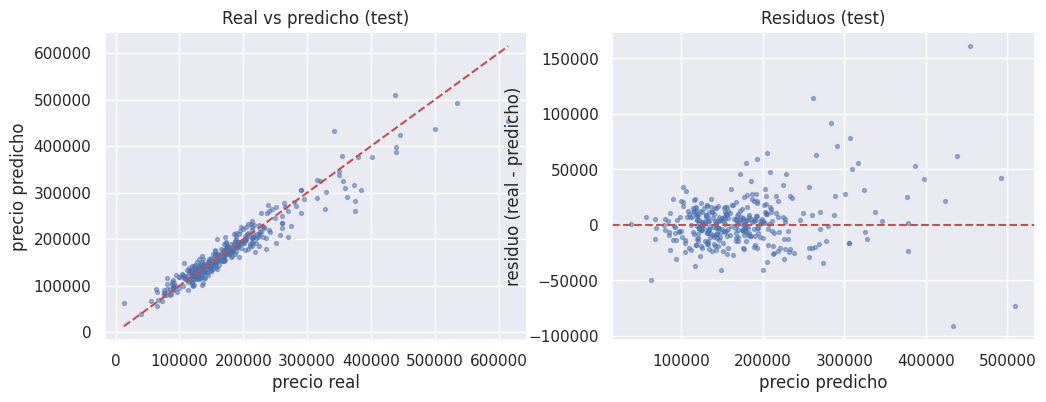

In [20]:
pred = modelo.predict(X_test)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(y_test, pred, s=8, alpha=.5)
lim = [y_test.min(), y_test.max()]
ax[0].plot(lim, lim, "r--"); ax[0].set_xlabel("precio real"); ax[0].set_ylabel("precio predicho"); ax[0].set_title("Real vs predicho (test)")
ax[1].scatter(pred, y_test - pred, s=8, alpha=.5); ax[1].axhline(0, color="r", ls="--")
ax[1].set_xlabel("precio predicho"); ax[1].set_ylabel("residuo (real - predicho)"); ax[1].set_title("Residuos (test)")
plt.show()

In [21]:
# ¿dónde se equivoca más el modelo? error por tercil de precio real
terciles = pd.qcut(y_test, 3, labels=["bajo", "medio", "alto"])
err = (y_test - pred).abs()
pd.DataFrame({"MAE (USD)": err.groupby(terciles).mean(),
              "error relativo medio": (err / y_test).groupby(terciles).mean()}).round(3)

,MAE (USD),error relativo medio
SalePrice,,
bajo,11914.712,0.141
medio,9508.794,0.059
alto,24389.855,0.087


### Variables más influyentes (importancia por permutación)

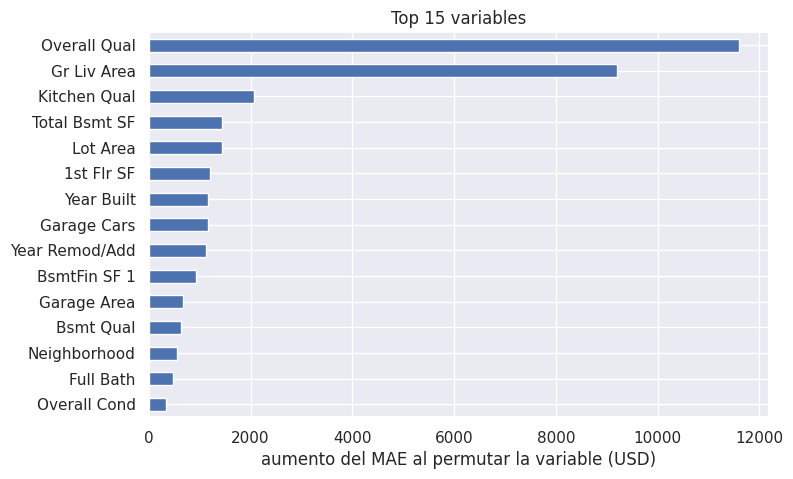

In [22]:
pi = permutation_importance(modelo, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE,
                            scoring="neg_mean_absolute_error", n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5)); imp.head(15)[::-1].plot.barh()
plt.xlabel("aumento del MAE al permutar la variable (USD)"); plt.title("Top 15 variables"); plt.show()

### Verificación adicional de fuga: variables de la venta

En 6.6 se conservaron `Sale Type`, `Sale Condition`, `Mo Sold` y `Yr Sold` por conocerse en el momento de la venta. Medimos cuánto aportan quitándolas (validación cruzada solo con train).

In [23]:
VARS_VENTA = ["Sale Type", "Sale Condition", "Mo Sold", "Yr Sold"]
cols_sin = [c for c in X_train.columns if c not in VARS_VENTA]
cv_sin = cross_validate(make_model(cols_sin), X_train[cols_sin], y_train, cv=cv,
                                         scoring={"MAE": "neg_mean_absolute_error"})
mae_con, mae_sin = cv_modelo["MAE"], -cv_sin["test_MAE"].mean()
print(f"MAE CV con variables de la venta: {mae_con:,.0f} | sin ellas: {mae_sin:,.0f} | diferencia: {mae_sin/mae_con-1:+.1%}")

MAE CV con variables de la venta: 15,594 | sin ellas: 16,168 | diferencia: +3.7%


Quitar esas variables empeora el error solo ligeramente (≈ 4%, muy lejos de la mejora de ≈ 70% sobre el baseline): aportan algo de información, pero el modelo no depende de ellas para acertar, así que no hay una fuga que infle las métricas. Se conservan porque describen la transacción que se quiere estimar; **si el modelo se usara para tasar una vivienda antes de venderla, habría que retirarlas**.

### 9.2 Reproducibilidad

- Semilla única `RANDOM_STATE = 42` para la partición, la validación cruzada y el modelo.
- El notebook se ejecuta de principio a fin sin intervención manual; las únicas rutas son `data/train.csv`, `data/test.csv` y `modelo.joblib`, relativas a esta carpeta.
- Dependencias documentadas en `requirements.txt`. Versiones usadas en la ejecución entregada:

In [24]:
print("python", platform.python_version(), "| pandas", pd.__version__, "| numpy", np.__version__, "| scikit-learn", sklearn.__version__)

python 3.12.3 | pandas 3.0.2 | numpy 2.4.4 | scikit-learn 1.8.0


### 9.3 Interpretación de resultados (8.2 de la especificación)

- **¿El modelo mejora al modelo base?** Sí, ampliamente: el MAE baja de ≈ 54 mil USD (predecir siempre la mediana) a ≈ 15 mil USD, una reducción de ≈ 70%; el R² pasa de ≈ 0 a ≈ 0.92 en test. La mejora se sostiene en validación cruzada y en test, y con desviación entre folds pequeña.
- **¿La métrica es razonable?** Sí. Un MAE de ≈ 15 mil USD es cerca del 8% del precio medio (≈ 179 mil USD) y el RMSLE de ≈ 0.14 equivale a un error relativo típico de ≈ 14%. El error de test es coherente con el de validación cruzada, lo que indica que no hay sobreajuste ni fuga apreciable. En términos absolutos el modelo se equivoca más en las viviendas más caras (≈ 24 mil USD en el tercio superior frente a ≈ 10–12 mil en el resto), mientras que en términos relativos las más baratas son las de mayor error (≈ 14%); ver la tabla por terciles.
- **Principales dificultades:** distinguir vacíos "no aplica" de datos perdidos; el gran número de variables categóricas; la presencia de variables redundantes (correlación > 0.8) y de pocos valores atípicos muy influyentes; decidir qué variables de la venta conservar sin fugar información.
- **Mejoras posibles:** ajustar hiperparámetros con búsqueda en validación cruzada; tratar o analizar los atípicos de área habitable; crear variables nuevas (edad de la vivienda, área total, baños totales); comparar políticas de imputación de `Lot Frontage` con pruebas de hipótesis como en 04.02; estimar la incertidumbre de las predicciones.

## 10. Almacenamiento del modelo

Se demuestra que el modelo puede **entrenarse** (sección 8), **guardarse**, **cargarse** y **generar predicciones** con el archivo guardado. Se guarda el `Pipeline` completo, por lo que acepta un DataFrame crudo con las columnas originales.

In [25]:
joblib.dump(modelo, MODEL_PATH)
print("modelo guardado en", MODEL_PATH, f"({os.path.getsize(MODEL_PATH)/1e6:.1f} MB)")

cargado = joblib.load(MODEL_PATH)
assert np.allclose(cargado.predict(X_test), modelo.predict(X_test))
print("modelo recargado: las predicciones coinciden con las del modelo en memoria")

metricas = {"modelo": "HistGradientBoostingRegressor (log1p del objetivo)",
            "test": res_test.loc["Gradient Boosting"].round(4).to_dict(),
            "baseline_test": res_test.loc["Baseline (mediana)"].round(4).to_dict(),
            "cv_train": {k: round(float(v), 4) for k, v in cv_modelo.items()},
            "random_state": RANDOM_STATE, "test_size": TEST_SIZE,
            "columnas_entrada": list(X.columns),
            "versiones": {"scikit-learn": sklearn.__version__, "pandas": pd.__version__}}
with open("metricas.json", "w") as f:
    json.dump(metricas, f, indent=2, ensure_ascii=False)

modelo guardado en modelo.joblib (1.2 MB)
modelo recargado: las predicciones coinciden con las del modelo en memoria


In [26]:
# Predicciones sobre datos NUEVOS (test.csv no tiene SalePrice), usando solo el modelo guardado
nuevos = pd.read_csv(NEW_DATA_PATH)
faltan = set(X.columns) - set(nuevos.columns)
print("columnas requeridas que faltan en los datos nuevos:", faltan or "ninguna")
salida = pd.DataFrame({"Id": nuevos["Id"], "SalePrice_predicho": cargado.predict(nuevos[X.columns]).round(0)})
print(f"{len(salida)} predicciones | mínimo {salida.SalePrice_predicho.min():,.0f} | máximo {salida.SalePrice_predicho.max():,.0f} USD")
salida.head()

columnas requeridas que faltan en los datos nuevos: ninguna


1172 predicciones | mínimo 46,774 | máximo 523,613 USD


,Id,SalePrice_predicho
0,0,165124.0
1,1,104792.0
2,2,184260.0
3,3,124743.0
4,4,110455.0
